In [24]:
import os
import deeptile
import matplotlib.pyplot as plt
import numpy as np
from deeptile.extensions import stitch
from tifffile import TiffFile
import tifffile
import dask.array as da
import utils
import skimage as ski
import importlib
import extract_features
import pandas as pd
from collections import defaultdict
from extract_features import features_basic, foci_features, feature_table, neighbor_measurements
from scipy import ndimage as ndi
import time
import sys
sys.path.append('/Users/hannahbolen/Desktop/image_analysis/whole_slide')
import segment_functions as fun

In [15]:
root_local = "/Users/hannahbolen/Desktop/image_analysis/"
img_name_local = "o8p_day7_s12.ome.tif"
img_path_local = os.path.join(root_local, img_name_local)
t0_local = time.time()
img = da.from_array(tifffile.imread(img_path_local)[0])
#dt_nuclei_local = deeptile.load(img_local[0,20826:20826+6144,20826:20826+6144])
#dt_foci_local = deeptile.load(img_local[1,20826:20826+6144,20826:20826+6144])
print("open time:", time.time() - t0_local)

open time: 3.5233840942382812


In [31]:
img_crop = img[20826:20826+6144,20826:20826+6144]
umPerPx = 0.325
nucleiThreshold = 50
nucleiMin = 150/umPerPx**2
nucleiMax = 12000
nucleiMean = 300/umPerPx**2
smooth=3


In [36]:
# timer
importlib.reload(fun)
fun.OPS_PROFILE = True
fun.OPS_PROFILE_VERBOSE = True
fun.ops_timing_reset()
# nuclei segmentation arguments
nucleiArgs = dict(threshold=lambda x: nucleiThreshold, 
            area_min=nucleiMin, area_max=nucleiMax,
            smooth=smooth)
# segment nuclei
nuclei = fun.find_nuclei(img_crop.compute(), **nucleiArgs)
fun.ops_timing_summary()

[ops_timer] simple_binary: 0.782s
[ops_timer] label: 0.061s
[ops_timer] filter_by_region_initial: 0.357s
[ops_timer] fill_holes: 0.463s
[ops_timer] label_hole_diff: 0.062s
[ops_timer] filter_by_region_holes: 0.402s
[ops_timer] apply_hole_fill: 0.002s
[ops_timer] watershed: 2.921s
[ops_timer] filter_by_region_final: 0.361s


['watershed                   2.921s   54.0%\n',
 'simple_binary               0.782s   14.4%\n',
 'fill_holes                  0.463s    8.6%\n',
 'filter_by_region_holes      0.402s    7.4%\n',
 'filter_by_region_final      0.361s    6.7%\n',
 'filter_by_region_initial    0.357s    6.6%\n',
 'label_hole_diff             0.062s    1.2%\n',
 'label                       0.061s    1.1%\n',
 'apply_hole_fill             0.002s    0.0%\n',
 'total                       5.410s  100.0%\n']

In [ ]:
threshold = 7
mask = ski.util.img_as_ubyte(ski.filters.gaussian(img_crop, sigma = 1.8)) >= threshold
mask = ski.morphology.remove_small_objects(mask, min_size=nucleiMin)
labeled = ski.measure.label(mask)
labeled = fun.filter_by_region(labeled, threshold=lambda x: nucleiThreshold, intensity_image=img_crop) > 0
filled = ndi.binary_fill_holes(labeled)
difference = ski.measure.label(filled != labeled)
change = fun.filter_by_region(difference, score=lambda r: r.area < nucleiMin, threshold=0) > 0
labeled[change] = filled[change]
nuclei = fun.apply_watershed(labeled,smooth=4)
result = fun.filter_by_region(nuclei, score=lambda r: nucleiMin < r.area < nucleiMax, threshold=nucleiThreshold)
boundaries = ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(img_crop,in_range = (256, 12000)), result, mode="thick")

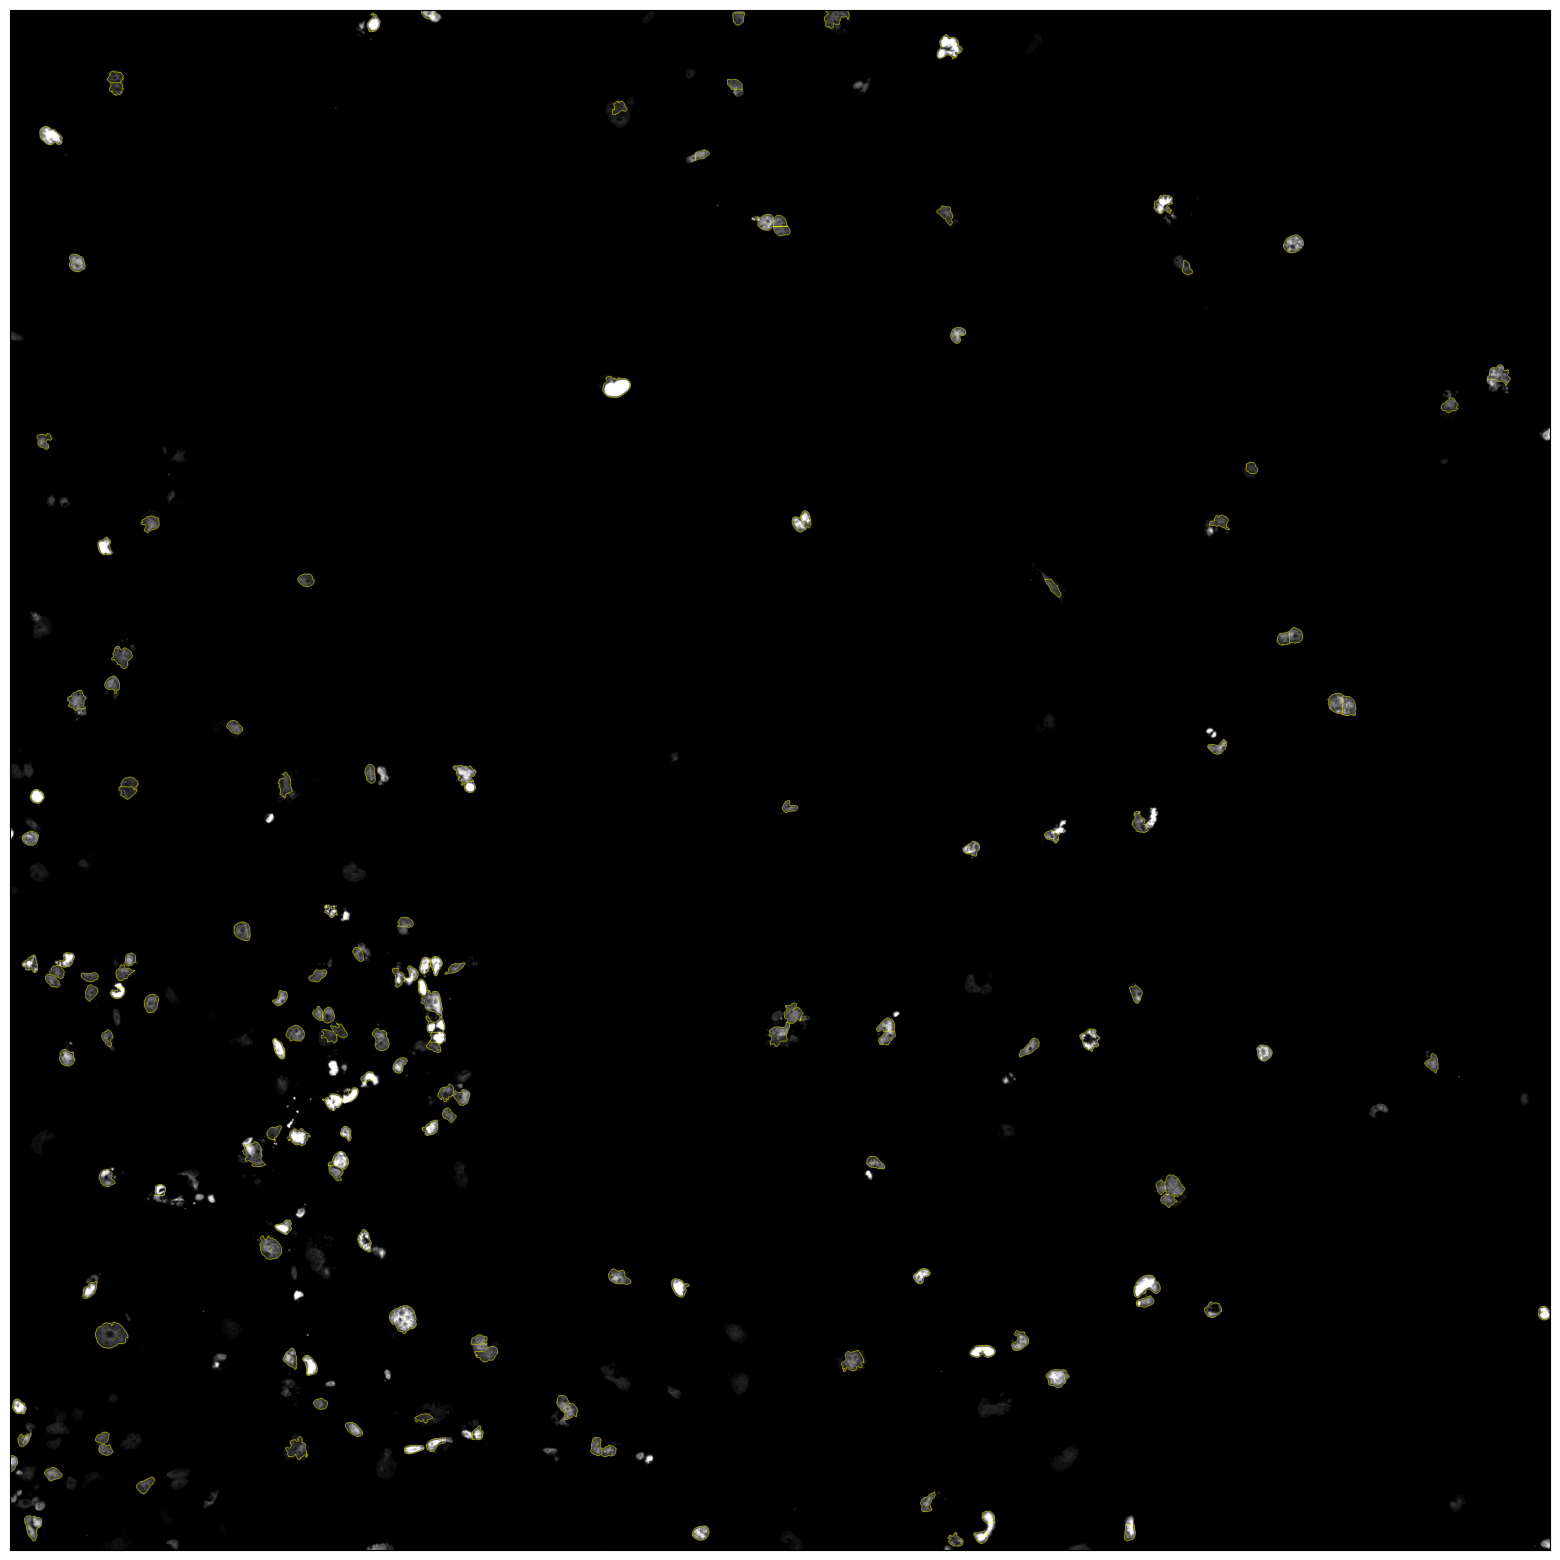

In [50]:
fig, ax = plt.subplots(figsize=(20,20))
ax.imshow(boundaries)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

In [2]:
root = "/Users/hannahbolen/server_mount/tiff_images/"
img_name = "o8p_day7_s12.ome.tif"
img_path = os.path.join(root, img_name)
t0 = time.time()
img = da.from_zarr(tifffile.imread(img_path, aszarr=True))
dt_nuclei = deeptile.load(img[0,20826:20826+6144,20826:20826+6144])
#dt_foci = deeptile.load(img[1,20826:20826+6144,20826:20826+6144])
print("open time:", time.time() - t0)

open time: 0.5578739643096924


In [41]:
# Configure
dt_nuclei = deeptile.load(img_crop)
overlap = (0.1, 0.1)
tile_size = (2048, 2048)
# Get nuceli tiles
tiles_nuclei = dt_nuclei.get_tiles(tile_size, overlap)
tiles_nuclei = tiles_nuclei.pad()
# Get foci tiles
# tiles_foci = dt_foci.get_tiles(tile_size, overlap)
# tiles_foci = tiles_foci.pad()

In [42]:
# Segment tiles and stitch
t0 = time.time()
model_parameters = {'gpu': True, 'model_type': 'nuclei'}
eval_parameters = {'diameter': 60}
cellpose = utils.cellpose_segmentation(model_parameters, eval_parameters)

masks_nuclei = cellpose(tiles_nuclei)
t2 = time.time()
mask_nuclei = stitch.stitch_masks(masks_nuclei)
t3 = time.time()
print("cellpose w remote images run time:", time.time() - t0, "tile size:", tiles_nuclei[0,0].shape, "num tiles:", tiles_nuclei.size)

2026-03-19 14:42:17,050 [INFO] WRITING LOG OUTPUT TO /Users/hannahbolen/.cellpose/run.log
2026-03-19 14:42:17,050 [INFO] 
cellpose version: 	4.0.8 
platform:       	darwin 
python version: 	3.11.14 
torch version:  	2.9.1
2026-03-19 14:42:17,050 [WARNING] model_type argument is not used in v4.0.1+. Ignoring this argument...
2026-03-19 14:42:17,073 [INFO] ** TORCH MPS version installed and working. **
2026-03-19 14:42:17,074 [INFO] >>>> using GPU (MPS)
2026-03-19 14:42:17,712 [INFO] >>>> loading model /Users/hannahbolen/.cellpose/models/cpsam
2026-03-19 14:42:18,119 [INFO] processing grayscale image with (2048, 2048) HW
2026-03-19 14:42:24,845 [INFO] processing grayscale image with (2048, 2048) HW
2026-03-19 14:42:31,250 [INFO] processing grayscale image with (2048, 2048) HW
2026-03-19 14:42:37,647 [INFO] processing grayscale image with (2048, 2048) HW
2026-03-19 14:42:44,018 [INFO] processing grayscale image with (2048, 2048) HW
2026-03-19 14:42:50,537 [INFO] processing grayscale image

In [52]:
filter_mask_nuclei = fun.filter_by_region(mask_nuclei, threshold = 50, intensity_image=img_crop)

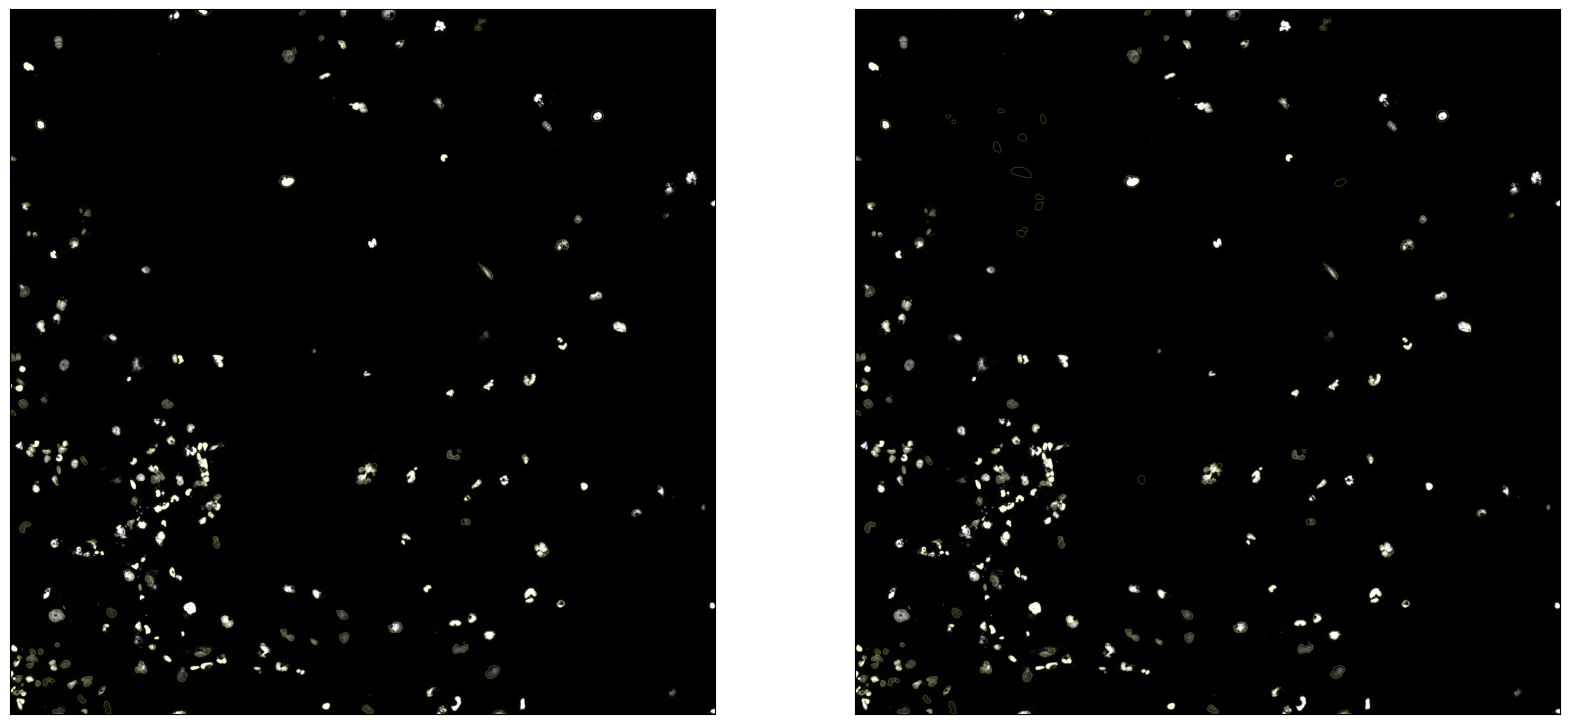

In [54]:
fig, ax = plt.subplots(ncols = 2, figsize=(20,20))
ax[0].imshow(ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(img_crop,in_range = (0, 5000)), filter_mask_nuclei, mode="thick"))
ax[1].imshow(ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(img_crop,in_range = (0, 5000)), mask_nuclei, mode="thick"))
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
plt.show()

In [46]:
ax.shape

(2,)

In [4]:
# Configure
overlap = (0.1, 0.1)
tile_size = (2048, 2048)
# Get nuceli tiles
tiles_nuclei_local = dt_nuclei_local.get_tiles(tile_size, overlap)
tiles_nuclei_local = tiles_nuclei_local.pad()
# # Get foci tiles
# tiles_foci = dt_foci.get_tiles(tile_size, overlap)
# tiles_foci = tiles_foci.pad()

In [ ]:
# Segment tiles and stitch
tlocal = time.time()
model_parameters = {'gpu': True, 'model_type': 'nuclei'}
eval_parameters = {'diameter': 60}
cellpose = utils.cellpose_segmentation(model_parameters, eval_parameters)

masks_nuclei_local = cellpose(tiles_nuclei_local)
t2 = time.time()
mask_nuclei_local = stitch.stitch_masks(masks_nuclei_local)
t3 = time.time()
print("cellpose w local images run time:", time.time() - tlocal, "tile size:", tiles_nuclei_local[0,0].shape, "num tiles:", tiles_nuclei_local.size)

In [10]:
ts = time.time()
tifffile.imwrite(os.path.join(root_local, "".join([img_name_local.split(".")[0], "_nuclei_mask"])), mask_nuclei_local.astype("uint16"))
print("save mask locally time:", time.time()-ts)

save mask locally time: 0.020341157913208008


In [7]:
root_server = "/Users/hannahbolen/server_mount/masks/"
tss = time.time()
tifffile.imwrite(os.path.join(root_server, "".join([img_name.split(".")[0], "_nuclei_mask2"])), mask_nuclei.astype("uint16"))
print("save mask to server time:", time.time()-tss)

save mask to server time: 19.105276346206665


In [ ]:
t0 = time()
# Segment tiles and stitch
model_parameters = {'gpu': True, 'model_type': 'nuclei'}
eval_parameters = {'diameter': 60}
cellpose = utils.cellpose_segmentation(model_parameters, eval_parameters)

masks_nuclei2048 = cellpose(tiles_nuclei2048)

mask_nuclei2048 = stitch.stitch_masks(masks_nuclei2048)

print(f"""
Total time for {tiles_nuclei2048.size} 2048x2048 tiles: {round((finish_stitching_2048-start_2048)//60)} min {round((finish_stitching_2048-start_2048)%60)} sec.
Time for cellpose: {round((finish_cellpose_2048-start_2048)//60)} min {round((finish_cellpose_2048-start_2048)%60)} sec.
Time for stitching: {round((finish_stitching_2048-finish_cellpose_2048)//60)} min {round((finish_stitching_2048-finish_cellpose_2048)%60)} sec.
""")